---

title: "Concatenating, Joining, and Pivoting Data"

author: Carly Waldeck

format:

  html:

    embed-resources: true

---


# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [2]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [7]:
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base +  "movies.dat"
ratings_url = base + "ratings.dat"
users_url = base + "users.dat"

movies_df = pd.read_csv(movies_url, 
                            sep="::", 
                            encoding_errors="ignore", 
                            header = None, 
                            names = ["movie_id", "title", "genre"])
ratings_df = pd.read_csv(ratings_url, 
                            sep="::", 
                            encoding_errors="ignore", 
                            header = None, 
                            names = ["user_id", "movie_id", "rating", "timestamp"])
users_df = pd.read_csv(users_url, 
                            sep="::", 
                            encoding_errors="ignore", 
                            names = ["user_id", "gender", "age", "occupation", "zip"])


<positron-console-cell-7>:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-7>:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-7>:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [30]:
# YOUR CODE HERE
users_ratings = ratings_df.merge(users_df, on="user_id", how="left", validate="many_to_one")
age_labels = {1:"<18", 18:"18-24", 25:"25-34", 35: "35-44", 45:"45-49", 50:"50-55", 56:"56+"}
users_ratings["age_group"] = users_ratings["age"].map(age_labels)

In [ ]:
(users_ratings.groupby("age_group")["rating"]
.agg(n_ratings = "size", mean_rating = "mean")
.sort_values("mean_rating", ascending=False)
.reset_index)

<bound method DataFrame.reset_index of            n_ratings  mean_rating
age_group                        
56+            38780     3.766632
50-55          72490     3.714512
45-49          83633     3.638062
35-44         199003     3.618162
<18            27211     3.549520
25-34         395556     3.545235
18-24         183536     3.507573>

56+ year olds tend to give the highest ratings. 

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [58]:
movie_ratings = pd.merge(movies_df,ratings_df,on='movie_id')

In [59]:
avg_ratings = movie_ratings.groupby('movie_id')['rating'].mean().reset_index().rename(columns={'rating':'AvgRating'})
num_ratings = movie_ratings.groupby('movie_id')['rating'].count().reset_index().rename(columns={'rating':'NumRating'})

In [60]:
df_movies_with_ratings =  movies_df.merge(avg_ratings,on='movie_id').merge(num_ratings,on='movie_id')

In [61]:
df_movies_with_100_ratings = df_movies_with_ratings[df_movies_with_ratings['NumRating']>=100]

In [62]:
df_movies_with_100_ratings.loc[df_movies_with_100_ratings['AvgRating'].idxmax()]

movie_id                                                  2019
title        Seven Samurai (The Magnificent Seven) (Shichin...
genre                                             Action|Drama
AvgRating                                              4.56051
NumRating                                                  628
Name: 1839, dtype: object

In [63]:
df_movies_with_100_ratings.loc[df_movies_with_100_ratings['AvgRating'].idxmin()]

movie_id                           810
title                    Kazaam (1996)
genre        Children's|Comedy|Fantasy
AvgRating                     1.466667
NumRating                          120
Name: 764, dtype: object

Seven Samuraui  is the highest rated and Kazaam the lowest rated

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

<Axes: xlabel='avg_rating', ylabel='prop_18_24'>

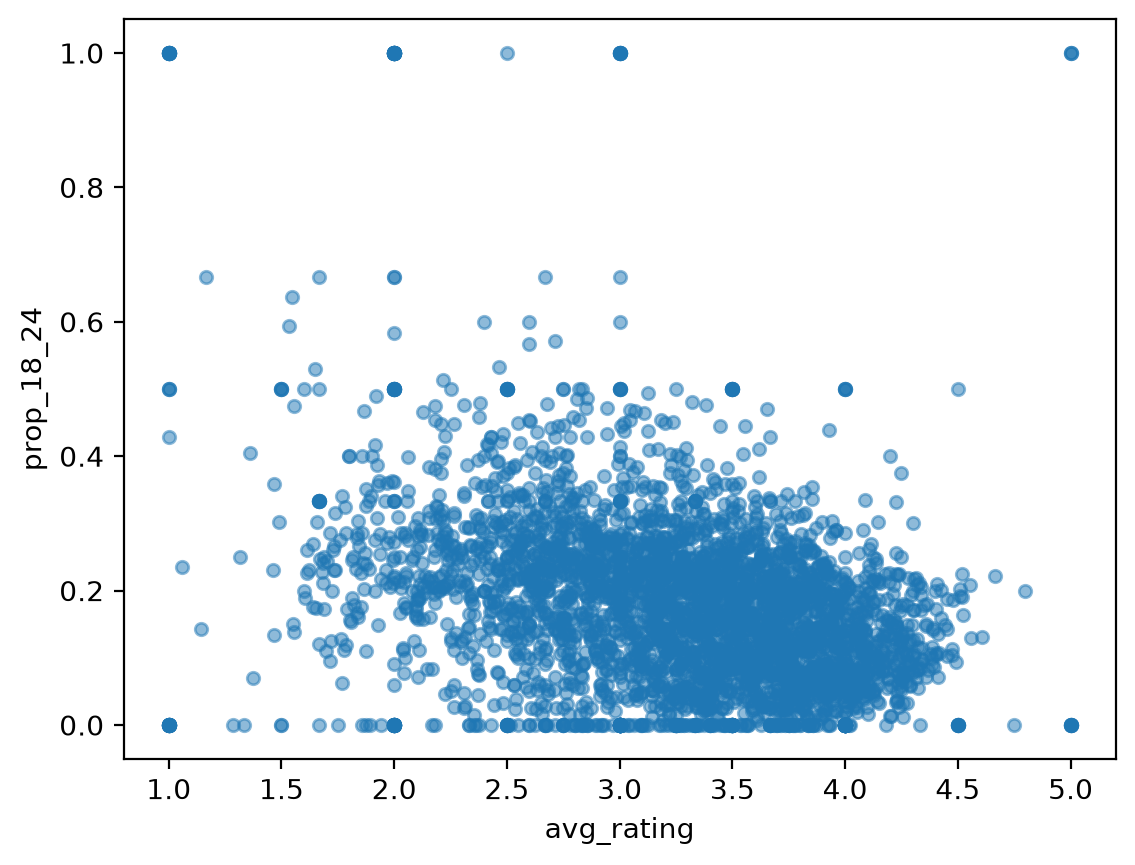

In [ ]:
# YOUR CODE HERE
movie_summary = users_ratings.groupby("movie_id").agg(
    avg_rating=("rating", "mean"),
    prop_18_24=("age_group", lambda x: (x == "18-24").mean()),
    n_ratings=("rating", "count")
)

movie_summary.plot.scatter(
    x="avg_rating",
    y="prop_18_24",
    alpha=0.5
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [42]:
# YOUR CODE HERE
movies_df.merge(
    ratings_df[["movie_id"]],
    on="movie_id",
    how="left_anti"
).shape[0]

177

177 movies had 0 ratings

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [64]:
one_star = ratings_df[ratings_df["rating"] == 1].groupby("movie_id").size().reset_index(name="one_star")

five_star = ratings_df[ratings_df["rating"] == 5].groupby("movie_id").size().reset_index(name="five_star")

both = one_star.merge(five_star, on="movie_id").merge(movies_df, on="movie_id")

both

,movie_id,one_star,five_star,title,genre
0,1,16,820,Toy Story (1995),Animation|Children's|Comedy
1,2,42,48,Jumanji (1995),Adventure|Children's|Fantasy
2,3,44,43,Grumpier Old Men (1995),Comedy|Romance
3,4,21,6,Waiting to Exhale (1995),Comedy|Drama
4,5,28,16,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...
2981,3948,35,163,Meet the Parents (2000),Comedy
2982,3949,9,132,Requiem for a Dream (2000),Drama
2983,3950,2,12,Tigerland (2000),Drama
2984,3951,1,14,Two Family House (2000),Drama


In [65]:
both.shape[0]

2986

2986 movies recieved both 1 star and 5 star ratings